In [ ]:
import ee
import geemap
import ipywidgets as widgets
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import firebase_admin
from firebase_admin import credentials, firestore
from datetime import datetime, timezone, timedelta
from IPython.display import display, clear_output, HTML
import warnings
warnings.filterwarnings('ignore')



def setup_thai_font():
    thai_fonts = ['Tahoma', 'TH Sarabun New', 'Cordia New', 'Angsana New',
                  'Leelawadee UI', 'Browallia New', 'Noto Sans Thai']
    available = set(f.name for f in fm.fontManager.ttflist)
    for fn in thai_fonts:
        if fn in available:
            plt.rcParams['font.family'] = fn
            plt.rcParams['axes.unicode_minus'] = False
            print(f"  Font: {fn}")
            return fn
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    return None

THAI_FONT = setup_thai_font()


# ══════════════════════════════════════════
# Firebase + GEE
# ══════════════════════════════════════════
if not firebase_admin._apps:
    cred = credentials.Certificate(r'C:\MyProject\BananaAI\firebase\banana-ai-67fd9-firebase-adminsdk-fbsvc-ad17503b9a.json')
    firebase_admin.initialize_app(cred)

db = firestore.client()

try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()


CONFIG = {
    # SCL Cloud Masking
    'scl_clear_classes': [4, 5, 6],            # 4=Vegetation, 5=Bare Soil, 6=Water
    'min_valid_pct': 0.70,                     # >=70% valid pixels required

    # Adaptive Window
    'windows': [5, 10, 15, 21],
    'cloud_limit_dry': 30,                     # Nov-Apr
    'cloud_limit_wet': 50,                     # May-Oct

    # Spike Detection
    'spike_threshold': 0.25,                   # NDVI change > 0.25 in one step = suspicious
    'ndvi_floor': 0.10,                        # NDVI < 0.10 always suspicious for banana

    # Health Score Weights
    'w_ndvi': 0.45, 'w_ndre': 0.30, 'w_ndmi': 0.15, 'w_evi': 0.10,

    # SAR
    'sar_window_days': 12,
    'sar_vh_min': -22, 'sar_vh_max': -4,       # dB range for normalization

    # DQS Weights
    'dqs_valid_pct_max': 40,
    'dqs_source_scores': {'S2_clean': 30, 'S2_expanded': 20, 'SAR': 12, 'spike': 5},
    'dqs_depth_max': 20,
    'dqs_season_dry': 10, 'dqs_season_wet': 5,
}

# Crop Classification
CROP_CONFIG = {
    'ndvi_std_threshold': 0.08, 'ndmi_banana_min': 0.20,
    'ndvi_durian_min': 0.70, 'temporal_months': 12, 'cloud_pct': 20, 'n_clusters': 3,
}
CROP_CLASSES = {0:{'name':'Durian','color':'#FF6F00','emoji':'🟠'},
                1:{'name':'Banana','color':'#4CAF50','emoji':'🟢'},
                2:{'name':'Other','color':'#9E9E9E','emoji':'⚪'}}
_crop_mask_cache = {'banana_mask':None,'durian_mask':None,'final_class':None,
                    'stats_img':None,'crop_stats':None,'created_date':None}


# ══════════════════════════════════════════
# 3-Layer Cloud Masking
# ══════════════════════════════════════════
def mask_clouds_scl(img):
    """Layer 2: SCL pixel-level cloud masking
    Keep only: 4=Vegetation, 5=Bare Soil, 6=Water
    Mask out: 3=Cloud Shadow, 7-10=Cloud/Cirrus"""
    scl = img.select('SCL')
    clear = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6))
    return img.updateMask(clear)


def check_valid_pixels(img, roi):
    """Layer 3: Check % of valid (non-masked) pixels
    Returns float 0.0-1.0"""
    
    valid_mask = img.select('B8').mask()  
    stats = valid_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi, scale=10, maxPixels=1e9
    ).getInfo()
    return stats.get('B8', 0) or 0


def get_clean_s2(roi, center_date, crop_mask=None):
  
    month = center_date.month
    cloud_limit = CONFIG['cloud_limit_wet'] if (5 <= month <= 10) else CONFIG['cloud_limit_dry']
    season = 'wet' if (5 <= month <= 10) else 'dry'

    for w in CONFIG['windows']:
        half = w // 2
        s_date = (center_date - timedelta(days=half)).strftime('%Y-%m-%d')
        e_date = (center_date + timedelta(days=half+1)).strftime('%Y-%m-%d')

        # Layer 1: Scene-level filter
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterBounds(roi)
               .filterDate(s_date, e_date)
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_limit)))

        n = col.size().getInfo()
        if n == 0:
            continue

        # Layer 2: SCL pixel-level masking on each image, then composite
        col_masked = col.map(mask_clouds_scl)
        composite = col_masked.median().clip(roi)

        # Layer 3: Valid pixel percentage check
        valid_pct = check_valid_pixels(composite, roi)

        if valid_pct < CONFIG['min_valid_pct']:
            # Not enough valid pixels — try wider window
            continue

        # Calculate indices
        if crop_mask is not None:
            composite = composite.updateMask(crop_mask)

        processed = calculate_indices(composite)

        stats = processed.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=roi, scale=10, maxPixels=1e9
        ).getInfo()

        if stats.get('NDVI') is not None:
            if valid_pct >= 0.90:
                quality = 'high'
            elif valid_pct >= 0.70:
                quality = 'medium'
            else:
                quality = 'low'

            return processed, round(valid_pct, 3), w, n, quality

    return None, 0, 0, 0, 'no_data'


# ══════════════════════════════════════════
# Vegetation Indices 
# ══════════════════════════════════════════
def calculate_indices(img):
    ndvi = img.normalizedDifference(['B8','B4']).rename('NDVI')
    ndmi = img.normalizedDifference(['B8','B11']).rename('NDMI')
    ndre = img.normalizedDifference(['B8','B5']).rename('NDRE')
    evi = img.expression(
        '2.5 * ((NIR - RED) / (NIR + 6.0 * RED - 7.5 * BLUE + 10000.0))',
        {'NIR':img.select('B8').toFloat(),'RED':img.select('B4').toFloat(),'BLUE':img.select('B2').toFloat()}
    ).clamp(-1, 1).rename('EVI')
    savi = img.expression(
        '1.5 * ((NIR - RED) / (NIR + RED + 5000.0))',
        {'NIR':img.select('B8').toFloat(),'RED':img.select('B4').toFloat()}
    ).clamp(-1, 1).rename('SAVI')
    return img.addBands([ndvi, ndmi, ndre, evi, savi])


# ══════════════════════════════════════════
# Health Score
# ══════════════════════════════════════════
def get_banana_grade(score):
    if score >= 0.55: return 'Excellent'
    elif score >= 0.40: return 'Good'
    elif score >= 0.25: return 'Warning'
    else: return 'Critical'

def get_health_score(ndvi, ndre=None, ndmi=None, evi=None):
    if ndvi is None: return None, "N/A"
    w = CONFIG
    score = (w['w_ndvi'] * (ndvi or 0) + w['w_ndre'] * (ndre or 0) +
             w['w_ndmi'] * (ndmi or 0) + w['w_evi'] * (evi or 0))
    grade = get_banana_grade(score)
    return round(score, 4), grade


# ══════════════════════════════════════════
# Data Quality Score (DQS)
# ══════════════════════════════════════════
def calculate_dqs(valid_pct, source_label, n_images, season, is_spike=False):
    c = CONFIG
    # Valid pixel coverage (0-40)
    pts_valid = min(valid_pct * c['dqs_valid_pct_max'], c['dqs_valid_pct_max'])

    # Source quality (0-30)
    if is_spike:
        pts_source = c['dqs_source_scores']['spike']
    elif 'SAR' in str(source_label):
        pts_source = c['dqs_source_scores']['SAR']
    elif 'expand' in str(source_label).lower() or any(f'({w}d' in str(source_label) for w in [10,15,21]):
        pts_source = c['dqs_source_scores']['S2_expanded']
    else:
        pts_source = c['dqs_source_scores']['S2_clean']

    # Composite depth (0-20)
    pts_depth = min(n_images * 5, c['dqs_depth_max'])

    # Season bonus (0-10)
    pts_season = c['dqs_season_dry'] if season == 'dry' else c['dqs_season_wet']

    return round(pts_valid + pts_source + pts_depth + pts_season, 1)


# ══════════════════════════════════════════
# Spike Detection
# ══════════════════════════════════════════
def detect_spike(current_ndvi, prev_ndvi, prev2_ndvi=None):
    if current_ndvi is None or prev_ndvi is None:
        return False, ""

    drop = prev_ndvi - current_ndvi

    # Rule 1: Sudden large drop
    if drop > CONFIG['spike_threshold']:
        # Check if it bounces back (prev2 was also low → might be real)
        if prev2_ndvi is not None and prev2_ndvi < prev_ndvi - 0.15:
            return False, ""  # Previous was also low — might be real decline
        return True, f"sudden drop {drop:+.2f}"

    # Rule 2: Unrealistically low for banana plantation
    if current_ndvi < CONFIG['ndvi_floor']:
        return True, f"below floor ({current_ndvi:.3f}<{CONFIG['ndvi_floor']})"

    return False, ""


# ══════════════════════════════════════════
# SAR Fallback (calibrated)
# ══════════════════════════════════════════
def get_sar_fallback(roi, center_date):
    try:
        w = CONFIG['sar_window_days']
        s_date = (center_date - timedelta(days=w)).strftime('%Y-%m-%d')
        e_date = (center_date + timedelta(days=w)).strftime('%Y-%m-%d')

        s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterBounds(roi).filterDate(s_date, e_date)
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
              .filter(ee.Filter.eq('instrumentMode', 'IW'))
              .select(['VH','VV']))

        if s1.size().getInfo() == 0:
            return None

        composite = s1.median().clip(roi)
        stats = composite.reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
        vh, vv = stats.get('VH'), stats.get('VV')
        if vh is None or vv is None:
            return None

        # === Derived SAR features ===
        vh_lin = 10 ** (vh / 10)
        vv_lin = 10 ** (vv / 10)
        rvi = (4 * vh_lin) / (vv_lin + vh_lin) if (vv_lin + vh_lin) > 0 else 0
        vh_vv_ratio = vh - vv  
        cr = vh_lin / vv_lin if vv_lin > 0 else 0  

     
        vh_norm = max(0, min(1, (vh - CONFIG['sar_vh_min']) / (CONFIG['sar_vh_max'] - CONFIG['sar_vh_min'])))
        rvi_norm = max(0, min(1, rvi / 1.5))  
        ratio_norm = max(0, min(1, (vh_vv_ratio + 15) / 15))  


        ndvi_est = (0.35 * vh_norm + 0.35 * rvi_norm + 0.30 * ratio_norm)
        ndvi_est = ndvi_est * 0.65 + 0.20  
        ndvi_est = max(0.15, min(0.85, ndvi_est))

        return {
            'NDVI': round(ndvi_est, 4),
            'sar_vh_db': round(vh, 2),
            'sar_vv_db': round(vv, 2),
            'sar_rvi': round(rvi, 4),
            'sar_vh_vv_ratio': round(vh_vv_ratio, 2),
            'sar_cross_ratio': round(cr, 4),
            'sar_model': 'multi_feature_v1.3',
        }
    except:
        return None


def collect_sar_calibration_pair(roi, center_date, optical_ndvi):

    global sar_calibration_pairs
    try:
        sar_data = get_sar_fallback(roi, center_date)
        if sar_data and optical_ndvi is not None:
            pair = {
                'date': center_date.strftime('%Y-%m-%d'),
                'optical_ndvi': round(optical_ndvi, 4),
                'sar_ndvi_est': sar_data['NDVI'],
                'sar_vh_db': sar_data['sar_vh_db'],
                'sar_vv_db': sar_data['sar_vv_db'],
                'sar_rvi': sar_data['sar_rvi'],
                'bias': round(optical_ndvi - sar_data['NDVI'], 4),
            }
            sar_calibration_pairs.append(pair)
            return pair
    except:
        pass
    return None


# ══════════════════════════════════════════
# Weather 
# ══════════════════════════════════════════
def get_weather_data(roi, start_date, end_date):
    weather = {}
    wp = roi.centroid(1)
    wr = wp.buffer(10000)

    try:
        chirps = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
                  .filterBounds(wp).filterDate(start_date, end_date))
        if chirps.size().getInfo() > 0:
            r_s = chirps.select('precipitation').sum().reduceRegion(
                ee.Reducer.mean(), wr, 5566, maxPixels=1e9).getInfo()
            d_s = chirps.select('precipitation').mean().reduceRegion(
                ee.Reducer.mean(), wr, 5566, maxPixels=1e9).getInfo()
            val = r_s.get('precipitation')
            val_d = d_s.get('precipitation')
            weather['rainfall_mm'] = round(val, 2) if val is not None else None
            weather['rainfall_daily_avg_mm'] = round(val_d, 2) if val_d is not None else None
        else:
            weather['rainfall_mm'] = None; weather['rainfall_daily_avg_mm'] = None
    except:
        weather['rainfall_mm'] = None; weather['rainfall_daily_avg_mm'] = None

    try:
        era5 = (ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
                .filterBounds(wp).filterDate(start_date, end_date))
        if era5.size().getInfo() > 0:
            t_img = ee.Image.cat([era5.select('temperature_2m').mean(),
                                  era5.select('temperature_2m').max(),
                                  era5.select('temperature_2m').min()]).rename(['t_m','t_x','t_n'])
            t_s = t_img.reduceRegion(ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
            tmk = t_s.get('t_m')
            if tmk and tmk > 200:
                weather['temp_mean_c'] = round(tmk - 273.15, 1)
                weather['temp_max_c'] = round((t_s.get('t_x') or tmk) - 273.15, 1)
                weather['temp_min_c'] = round((t_s.get('t_n') or tmk) - 273.15, 1)
                dew_s = era5.select('dewpoint_temperature_2m').mean().reduceRegion(
                    ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
                tdk = dew_s.get('dewpoint_temperature_2m')
                if tdk and tdk > 200:
                    tc, tdc = weather['temp_mean_c'], round(tdk - 273.15, 1)
                    rh = 100 * math.exp((17.625*tdc)/(243.04+tdc)) / math.exp((17.625*tc)/(243.04+tc))
                    weather['humidity_pct'] = round(min(max(rh,0),100), 1)
                else: weather['humidity_pct'] = None
            else:
                for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct']: weather[k] = None
            w_s = ee.Image.cat([era5.select('u_component_of_wind_10m').mean(),
                                era5.select('v_component_of_wind_10m').mean()]).rename(['u','v']).reduceRegion(
                ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo()
            u, v = w_s.get('u'), w_s.get('v')
            weather['wind_speed_ms'] = round(math.sqrt(u**2+v**2), 2) if u and v else None
            sv = era5.select('surface_solar_radiation_downwards_hourly').mean().reduceRegion(
                ee.Reducer.mean(), wr, 11132, maxPixels=1e9).getInfo().get('surface_solar_radiation_downwards_hourly')
            weather['solar_radiation_mj'] = round(sv*24/1e6, 2) if sv and sv > 0 else None
        else:
            for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj']: weather[k] = None
    except:
        for k in ['temp_mean_c','temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj']: weather[k] = None

    try:
        modis = (ee.ImageCollection('MODIS/061/MOD11A2').filterBounds(wp).filterDate(start_date, end_date))
        if modis.size().getInfo() > 0:
            lr = modis.select('LST_Day_1km').mean().reduceRegion(
                ee.Reducer.mean(), wr, 1000, maxPixels=1e9).getInfo().get('LST_Day_1km')
            weather['lst_day_c'] = round(lr*0.02-273.15, 1) if lr and lr > 0 else None
        else: weather['lst_day_c'] = None
    except: weather['lst_day_c'] = None

    return weather


# ══════════════════════════════════════════
# Trend Alert + Correlation 
# ══════════════════════════════════════════
def check_trend_alert(data_log, window=3):
    ndvi_vals = [d['NDVI'] for d in data_log if d.get('NDVI') is not None and not d.get('is_spike', False)]
    if len(ndvi_vals) < window + 1:
        return 'insufficient', 'Insufficient reliable data for trend'
    consecutive = 0
    for i in range(len(ndvi_vals)-1, 0, -1):
        if ndvi_vals[i] < ndvi_vals[i-1]: consecutive += 1
        else: break
    recent = ndvi_vals[-window:]
    chg = recent[-1] - recent[0]
    pct = (chg / recent[0]) * 100 if recent[0] != 0 else 0
    if consecutive >= 3 and pct < -10:
        return 'critical', f'CRITICAL: NDVI dropped {consecutive} periods ({pct:+.1f}%)'
    elif consecutive >= 2 and pct < -5:
        return 'warning', f'WARNING: NDVI declining {consecutive} periods ({pct:+.1f}%)'
    elif pct > 10:
        return 'improving', f'IMPROVING: NDVI up {pct:+.1f}%'
    else:
        return 'stable', f'STABLE: NDVI change {pct:+.1f}%'


def analyze_weather_correlation(data_log, lag_weeks=[0, 1, 2, 3, 4]):
    clean = [d for d in data_log if d.get('NDVI') is not None and not d.get('is_spike', False)]
    if len(clean) < 8: return None
    df = pd.DataFrame(clean)
    w_cols = ['rainfall_mm','temp_mean_c','humidity_pct','wind_speed_ms','solar_radiation_mj']
    avail = [c for c in w_cols if c in df.columns and df[c].notna().sum() >= 5]
    if not avail or 'NDVI' not in df.columns: return None

    results = {}
    for col in avail:
        best_r, best_lag = 0, 0
        for lag in lag_weeks:
            if lag == 0:
                v = df[['NDVI', col]].dropna()
            else:
                shifted = df[[col]].shift(lag)
                v = pd.concat([df['NDVI'], shifted[col]], axis=1).dropna()
            if len(v) >= 5 and v[col].std() > 0.001 and v['NDVI'].std() > 0.001:
                r = v['NDVI'].corr(v[col])
                if not np.isnan(r) and abs(r) > abs(best_r):
                    best_r, best_lag = r, lag
        if abs(best_r) > 0.01:
            results[col] = {'r': round(best_r, 3), 'lag': best_lag}
    return results if results else None


# ══════════════════════════════════════════
# Crop Classification 
# ══════════════════════════════════════════
def classify_temporal(roi, end_date_str):
    end_date = pd.to_datetime(end_date_str)
    start_date = end_date - pd.DateOffset(months=CROP_CONFIG['temporal_months'])
    s_str, e_str = start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')
    ndvi_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterBounds(roi).filterDate(s_str, e_str)
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CROP_CONFIG['cloud_pct']))
                .map(lambda img: mask_clouds_scl(img).normalizedDifference(['B8','B4']).rename('NDVI')
                     .copyProperties(img, ['system:time_start'])))
    ndvi_mean = ndvi_col.mean().rename('ndvi_mean')
    ndvi_std = ndvi_col.reduce(ee.Reducer.stdDev()).rename('ndvi_std')
    ndmi_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                .filterBounds(roi).filterDate(s_str, e_str)
                .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CROP_CONFIG['cloud_pct']))
                .map(lambda img: mask_clouds_scl(img).normalizedDifference(['B8','B11']).rename('NDMI')
                     .copyProperties(img, ['system:time_start'])))
    ndmi_mean = ndmi_col.mean().rename('ndmi_mean')
    is_banana = ndvi_std.gt(CROP_CONFIG['ndvi_std_threshold']).And(ndmi_mean.gt(CROP_CONFIG['ndmi_banana_min']))
    is_durian = ndvi_std.lte(CROP_CONFIG['ndvi_std_threshold']).And(ndvi_mean.gt(CROP_CONFIG['ndvi_durian_min']))
    final = ee.Image(2).where(is_durian, 0).where(is_banana, 1).rename('crop_class')
    stats_img = ee.Image.cat([ndvi_mean, ndvi_std, ndmi_mean])
    return final.clip(roi), stats_img.clip(roi)

def get_crop_statistics(roi, final_class, stats_img):
    stats = {}
    for cid, info in CROP_CLASSES.items():
        mask = final_class.eq(cid)
        pc = mask.reduceRegion(ee.Reducer.sum(), roi, 10, maxPixels=1e9).getInfo()
        count = pc.get('crop_class', 0) or 0
        idx = stats_img.updateMask(mask).reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
        stats[cid] = {'name':info['name'],'emoji':info['emoji'],'pixels':count,
                       'area_rai':round(count*100/1600,2),
                       'ndvi_mean':round(idx.get('ndvi_mean',0) or 0,4),
                       'ndvi_std':round(idx.get('ndvi_std',0) or 0,4),
                       'ndmi_mean':round(idx.get('ndmi_mean',0) or 0,4)}
    total = sum(s['pixels'] for s in stats.values())
    for c in stats: stats[c]['pct'] = round(stats[c]['pixels']/total*100,1) if total > 0 else 0
    return stats

def setup_crop_mask(roi, end_date_str):
    global _crop_mask_cache
    print(f"{'='*60}\n  Crop Classification ({end_date_str})\n{'='*60}")
    final_class, stats_img = classify_temporal(roi, end_date_str)
    banana_mask = final_class.eq(1).rename('banana_mask')
    durian_mask = final_class.eq(0).rename('durian_mask')
    crop_stats = get_crop_statistics(roi, final_class, stats_img)
    for cid, s in sorted(crop_stats.items()):
        print(f"  {s['emoji']} {s['name']:8s}: {s['area_rai']:6.2f} rai ({s['pct']:5.1f}%)")
    _crop_mask_cache.update({'banana_mask':banana_mask,'durian_mask':durian_mask,
        'final_class':final_class,'stats_img':stats_img,'crop_stats':crop_stats,'created_date':end_date_str})
    Map.addLayer(final_class, {'min':0,'max':2,'palette':['#FF6F00','#4CAF50','#9E9E9E']}, f'Crop Map ({end_date_str})')
    print(f"  Done!\n{'='*60}")
    return banana_mask


# ══════════════════════════════════════════
# Global Data Store 
# ══════════════════════════════════════════
data_log = []          
sar_calibration_pairs = []  



# ══════════════════════════════════════════
# GUI
# ══════════════════════════════════════════
style = {'description_width': 'initial'}
date_picker_start = widgets.DatePicker(description='Start:', value=datetime(2024, 1, 1), style=style)
date_picker_end = widgets.DatePicker(description='End:', value=datetime(2026, 12, 31), style=style)
farm_name_input = widgets.Text(description='Farm:', value='Banana_Farm_Zone_A', style=style)
weather_toggle = widgets.Checkbox(value=True, description='Weather Data', style=style, layout=widgets.Layout(width='300px'))
crop_mask_toggle = widgets.Checkbox(value=False, description='Crop Masking (Banana Only)', style=style, layout=widgets.Layout(width='300px'))
sar_toggle = widgets.Checkbox(value=True, description='SAR Fallback', style=style, layout=widgets.Layout(width='300px'))
step_dropdown = widgets.Dropdown(options=[('Every 5 days',5),('Every 7 days',7),('Every 10 days',10)], value=5, description='Step:', style=style)
btn_create_mask = widgets.Button(description='Create Crop Mask', button_style='warning', layout=widgets.Layout(width='100%'))
btn_start = widgets.Button(description='Start Analysis v1.3.0', button_style='primary', layout=widgets.Layout(width='100%', height='40px'))
log_output = widgets.Output(layout={'border':'1px solid #4CAF50','height':'400px','overflow_y':'scroll','padding':'5px'})
graph_output = widgets.Output()

banana_coords = [[99.264626,10.715821],
                 [99.264764,10.715965],
                 [99.265084,10.716047],
                 [99.265112,10.715756],
                 [99.265331,10.715375],
                 [99.265404,10.715139],
                 [99.265512,10.714932],
                 [99.265567,10.714722],
                 [99.265497,10.714756],
                 [99.265109,10.715200]]

fixed_roi = ee.Geometry.Polygon(banana_coords)
corner_points = ee.Geometry.MultiPoint(banana_coords)

def on_create_mask(b):
    log_output.clear_output()
    with log_output:
        try: end_str = pd.to_datetime(date_picker_end.value).strftime('%Y-%m-%d')
        except: end_str = '2026-01-17'
        setup_crop_mask(fixed_roi, end_str)
        crop_mask_toggle.value = True
btn_create_mask.on_click(on_create_mask)




# ══════════════════════════════════════════
# MAIN PROCESS 
# ══════════════════════════════════════════
def process_analysis(b):
    global data_log, sar_calibration_pairs
    data_log = []
    sar_calibration_pairs = []
    cloud_gaps = []
    log_output.clear_output()
    graph_output.clear_output()

    use_mask = crop_mask_toggle.value and _crop_mask_cache['banana_mask'] is not None
    b_mask = _crop_mask_cache['banana_mask'] if use_mask else None

    with log_output:
        mask_label = "Banana Only" if use_mask else "Whole Farm"
        print(f"{'='*65}")
        print(f"  BananaAI v1.3.0 — {farm_name_input.value} [{mask_label}]")
        print(f"  Cloud Masking: SCL 3-Layer | Spike Detection: ON")
        print(f"  Weather: {'ON' if weather_toggle.value else 'OFF'}"
              f" | SAR: {'ON' if sar_toggle.value else 'OFF'}"
              f" | Step: {step_dropdown.value}d")
        print(f"{'='*65}")

        roi = fixed_roi
        try:
            start_date = pd.to_datetime(date_picker_start.value)
            end_date = pd.to_datetime(date_picker_end.value)
        except Exception as e:
            print(f"Date error: {e}"); return

        step_days = step_dropdown.value
        total_steps = ((end_date - start_date).days // step_days) + 1
        thai_tz = timezone(timedelta(hours=7))
        current_date = start_date
        last_good_image, last_good_date = None, None
        counters = {'S2_clean':0, 'S2_expand':0, 'SAR':0, 'cloud':0, 'spike':0, 'total':0}

        for i in range(total_steps):
            if current_date > end_date: break
            date_str = current_date.strftime('%Y-%m-%d')
            month = current_date.month
            season = 'wet' if (5 <= month <= 10) else 'dry'
            counters['total'] += 1
            entry = {'Date': current_date, 'date_str': date_str, 'season': season}

            try:
                # === v1.2.0: 3-LAYER CLEAN S2 ===
                processed, valid_pct, window_used, n_imgs, quality = get_clean_s2(roi, current_date, b_mask)

                if processed is not None:
                    stats = processed.reduceRegion(ee.Reducer.mean(), roi, 10, maxPixels=1e9).getInfo()
                    val_ndvi = stats.get('NDVI')
                    val_ndmi = stats.get('NDMI')
                    val_ndre = stats.get('NDRE')
                    val_evi = stats.get('EVI')
                    val_savi = stats.get('SAVI')

                    if val_ndvi is not None:
                        # === SPIKE DETECTION ===
                        prev_ndvi = data_log[-1].get('NDVI') if data_log else None
                        prev2_ndvi = data_log[-2].get('NDVI') if len(data_log) >= 2 else None
                        is_spike, spike_reason = detect_spike(val_ndvi, prev_ndvi, prev2_ndvi)

                        if is_spike:
                            counters['spike'] += 1

                        # Source label
                        if window_used <= 5: counters['S2_clean'] += 1
                        else: counters['S2_expand'] += 1
                        src = f'S2({window_used}d,{n_imgs}img,{quality})'

                        # DQS
                        dqs = calculate_dqs(valid_pct, src, n_imgs, season, is_spike)

                        # Health
                        h_score, h_grade = get_health_score(val_ndvi, val_ndre, val_ndmi, val_evi)

                        entry.update({
                            'NDVI': val_ndvi, 'NDMI': val_ndmi, 'NDRE': val_ndre,
                            'EVI': val_evi, 'SAVI': val_savi,
                            'health_score': h_score, 'status': h_grade,
                            'source': src, 'valid_pct': valid_pct, 'dqs': dqs,
                            'is_spike': is_spike, 'spike_reason': spike_reason,
                            'crop_masked': use_mask,
                        })

                        # Weather
                        w_data = {}
                        if weather_toggle.value:
                            s_d = current_date.strftime('%Y-%m-%d')
                            e_d = (current_date + timedelta(days=step_days)).strftime('%Y-%m-%d')
                            w_data = get_weather_data(roi, s_d, e_d)
                            entry.update(w_data)

                        # Firebase
                        fb = {'farm_name':farm_name_input.value,'date':date_str,
                              'ndvi':round(val_ndvi,4),'ndmi':round(val_ndmi,4) if val_ndmi else None,
                              'ndre':round(val_ndre,4) if val_ndre else None,
                              'evi':round(val_evi,4) if val_evi else None,
                              'savi':round(val_savi,4) if val_savi else None,
                              'health_score':h_score,'status':h_grade,'source':src,
                              'valid_pct':valid_pct,'dqs':dqs,'is_spike':is_spike,
                              'crop_masked':use_mask,'timestamp':datetime.now(thai_tz),'version':'v1.3.0'}
                        if w_data:
                            fb.update({k:w_data.get(k) for k in ['rainfall_mm','rainfall_daily_avg_mm','temp_mean_c',
                                'temp_max_c','temp_min_c','humidity_pct','wind_speed_ms','solar_radiation_mj','lst_day_c']})
                        db.collection('banana_indices_logs').document(f"{farm_name_input.value}_{date_str}").set(fb)

                        # เก็บคู่ S2-SAR สำหรับ calibration
                        if window_used <= 5 and valid_pct >= 0.85 and not is_spike:
                            collect_sar_calibration_pair(roi, current_date, val_ndvi)

                        data_log.append(entry)

                        # Print
                        spike_tag = " ⚠️SPIKE" if is_spike else ""
                        dqs_tag = f" DQS:{dqs:.0f}"
                        w_str = ""
                        if w_data:
                            parts = []
                            if w_data.get('rainfall_mm') is not None: parts.append(f"R:{w_data['rainfall_mm']:.0f}mm")
                            if w_data.get('temp_mean_c') is not None: parts.append(f"T:{w_data['temp_mean_c']:.1f}C")
                            w_str = f" | {' '.join(parts)}" if parts else ""

                        print(f"  S2[{i+1}/{total_steps}] {date_str} "
                              f"NDVI:{val_ndvi:.3f} VP:{valid_pct:.0%}{dqs_tag}"
                              f"{w_str} -> {h_grade}{spike_tag}")

                        last_good_image = processed.select('NDVI')
                        last_good_date = date_str
                    else:
                        processed = None

                if processed is None and sar_toggle.value:
                    sar = get_sar_fallback(roi, current_date)
                    if sar:
                        counters['SAR'] += 1
                        dqs = calculate_dqs(0, 'SAR', 1, season)
                        entry.update({
                            'NDVI': sar['NDVI'], 'NDMI': None, 'NDRE': None,
                            'EVI': None, 'SAVI': None,
                            'health_score': round(sar['NDVI'] * CONFIG['w_ndvi'], 4),  # v1.3.0: ใช้ weight เดียวกัน
                            'status': get_banana_grade(sar['NDVI'] * CONFIG['w_ndvi']),  # v1.3.0 fix
                            'source': 'SAR', 'dqs': dqs, 'valid_pct': 0,
                            'is_spike': False, 'crop_masked': use_mask,
                        })
                        if weather_toggle.value:
                            w_data = get_weather_data(roi, current_date.strftime('%Y-%m-%d'),
                                (current_date + timedelta(days=step_days)).strftime('%Y-%m-%d'))
                            entry.update(w_data)
                        data_log.append(entry)
                        print(f"  SAR[{i+1}/{total_steps}] {date_str} NDVI(est):{sar['NDVI']:.3f} DQS:{dqs:.0f}")
                    else:
                        counters['cloud'] += 1; cloud_gaps.append(current_date)
                        print(f"  --[{i+1}/{total_steps}] {date_str} | No data")
                elif processed is None:
                    counters['cloud'] += 1; cloud_gaps.append(current_date)
                    print(f"  --[{i+1}/{total_steps}] {date_str} | No data")

            except Exception as e:
                print(f"  !![{i+1}] {date_str} | Error: {e}")

            current_date += timedelta(days=step_days)

        
        print(f"\n{'='*65}")
        print(f"  DATA QUALITY SUMMARY:")
        t = counters['total']
        for k, label, icon in [('S2_clean','S2 clean (SCL masked)','🟢'),
                                ('S2_expand','S2 expanded window','🟡'),
                                ('SAR','SAR fallback','📡'),('spike','Spike (suspicious)','⚠️'),
                                ('cloud','No data','❌')]:
            n = counters[k]; p = n/t*100 if t > 0 else 0
            bar = '█'*int(p/5) + '░'*(20-int(p/5))
            print(f"  {icon} {label:25s}: {n:3d}/{t} ({p:5.1f}%) {bar}")

        reliable = counters['S2_clean'] + counters['S2_expand']
        print(f"\n  Reliable for AI: {reliable}/{t} ({reliable/t*100:.1f}%)" if t > 0 else "")

        if data_log:
            dqs_vals = [d.get('dqs',0) for d in data_log if d.get('dqs')]
            if dqs_vals:
                print(f"  DQS: avg={np.mean(dqs_vals):.1f} min={np.min(dqs_vals):.0f} max={np.max(dqs_vals):.0f}")

        alert_msg = "Collecting data..."
        if len(data_log) >= 3:
            alert_type, alert_msg = check_trend_alert(data_log)
            print(f"\n  {alert_msg}")

        # SAR Calibration Summary
        if sar_calibration_pairs:
            pairs_df = pd.DataFrame(sar_calibration_pairs)
            mean_bias = pairs_df['bias'].mean()
            print(f"\n  SAR Calibration Data: {len(pairs_df)} paired observations")
            print(f"  Mean bias (optical - SAR): {mean_bias:+.3f}")
            print(f"  SAR RMSE: {np.sqrt((pairs_df['bias']**2).mean()):.3f}")
            if abs(mean_bias) > 0.15:
                print(f"  ⚠ SAR bias > 0.15 — ต้อง recalibrate model")

        if weather_toggle.value and len(data_log) >= 8:
            corrs = analyze_weather_correlation(data_log)
            if corrs:
                print(f"\n  Weather-NDVI Correlation (with lag):")
                for col, info in sorted(corrs.items(), key=lambda x: abs(x[1]['r']), reverse=True):
                    lag_str = f" (lag {info['lag']}w)" if info['lag'] > 0 else ""
                    strength = "Strong" if abs(info['r'])>0.5 else "Moderate" if abs(info['r'])>0.3 else "Weak"
                    print(f"   {col}: r={info['r']:+.3f}{lag_str} [{strength}]")

        print(f"{'='*65}")

        if last_good_image:
            vis = {'min':0,'max':1,'palette':['red','orange','yellow','#66cc00','#006600']}
            Map.addLayer(last_good_image, vis, f"NDVI ({last_good_date})")
            Map.centerObject(roi, 17)

    # === GRAPHS ===
    with graph_output:
        if data_log:
            df = pd.DataFrame(data_log)
            create_dashboard(df, farm_name_input.value, alert_msg, use_mask, cloud_gaps)




def format_ax(ax, title=''):
    ax.set_title(title, fontweight='bold', fontsize=11, pad=8)
    ax.grid(True, alpha=0.15, linewidth=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', labelsize=7, rotation=40)
    ax.tick_params(axis='y', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def add_zone_labels(ax, ymin=-0.05, ymax=1.05):
    zones = [(0.75,ymax,'#E8F5E9','Excellent','#2E7D32'),(0.60,0.75,'#F1F8E9','Good','#558B2F'),
             (0.40,0.60,'#FFF8E1','Warning','#F57F17'),(ymin,0.40,'#FBE9E7','Critical','#BF360C')]
    for y0,y1,bg,label,tc in zones:
        ax.axhspan(y0,y1,alpha=0.25,color=bg,zorder=0)
        ax.axhline(y=y0,color=tc,alpha=0.3,lw=0.5,ls='--',zorder=1)
        ax.text(1.01,(y0+y1)/2,label,transform=ax.get_yaxis_transform(),fontsize=6,color=tc,fontweight='bold',va='center')
    ax.set_ylim(ymin,ymax)

def shade_cloud_gaps(ax, gaps, step_days):
    if not gaps: return
    groups, cur = [], [gaps[0]]
    for g in gaps[1:]:
        if (g - cur[-1]).days <= step_days+2: cur.append(g)
        else: groups.append(cur); cur = [g]
    groups.append(cur)
    for grp in groups:
        if len(grp) >= 2:
            ax.axvspan(grp[0]-timedelta(days=2),grp[-1]+timedelta(days=2),alpha=0.06,color='#9E9E9E',zorder=0)

def create_dashboard(df, farm_name, alert_msg, crop_masked, cloud_gaps):
    mask_tag = " [Banana Only]" if crop_masked else ""
    step_d = step_dropdown.value
    has_spike = 'is_spike' in df.columns

    fig = plt.figure(figsize=(18, 26), facecolor='white')
    gs = GridSpec(5, 2, figure=fig, hspace=0.40, wspace=0.25, height_ratios=[1.2, 1.5, 1, 1, 0.8])
    fig.suptitle(f'BananaAI v1.3.0 — {farm_name}{mask_tag}\n{alert_msg}',
                 fontsize=13, fontweight='bold', y=0.98, color='#1B5E20')

    is_sar = df['source'].str.contains('SAR', na=False) if 'source' in df.columns else pd.Series([False]*len(df))
    is_spike_mask = df['is_spike'].fillna(False) if has_spike else pd.Series([False]*len(df))
    is_clean = ~is_sar & ~is_spike_mask

    # ═══ PANEL 1: NDVI Time Series ═══
    ax1 = fig.add_subplot(gs[0, :])
    add_zone_labels(ax1); shade_cloud_gaps(ax1, cloud_gaps, step_d)
    if is_clean.any():
        ax1.plot(df.loc[is_clean,'Date'], df.loc[is_clean,'NDVI'], 'o-', color='#1B5E20', lw=2.2, ms=4, mew=0, alpha=0.95, label='NDVI (Clean)', zorder=10)
    if is_sar.any():
        ax1.plot(df.loc[is_sar,'Date'], df.loc[is_sar,'NDVI'], 'D', color='#E65100', ms=5, mew=1, mec='#BF360C', alpha=0.8, label='NDVI (SAR est.)', zorder=11)
    if has_spike and is_spike_mask.any():
        ax1.plot(df.loc[is_spike_mask,'Date'], df.loc[is_spike_mask,'NDVI'], 'X', color='#D32F2F', ms=8, mew=2, alpha=0.9, label='Spike (suspicious)', zorder=12)
    ax1.plot(df.loc[~is_spike_mask,'Date'], df.loc[~is_spike_mask,'NDVI'], '-', color='#66BB6A', alpha=0.3, lw=1, zorder=3)
    ax1.set_ylabel('NDVI', fontsize=9, fontweight='bold')
    ax1.legend(loc='lower left', fontsize=8, framealpha=0.9, ncol=3)
    format_ax(ax1, f'NDVI Time Series (SCL Cloud-Masked){mask_tag}')

    # ═══ PANEL 2: ALL-IN-ONE Indices + Weather ═══
    ax2 = fig.add_subplot(gs[1, :])
    add_zone_labels(ax2); shade_cloud_gaps(ax2, cloud_gaps, step_d)
    all_lines = []
    for col, color, mk, lw, ms, label in [('NDVI','#1B5E20','o',2.5,4,'NDVI'),('NDRE','#B71C1C','s',2.0,3,'NDRE'),('NDMI','#0D47A1','D',2.0,3,'NDMI')]:
        if col in df.columns:
            valid = df[col].notna() & ~is_spike_mask
            if valid.any():
                ln = ax2.plot(df.loc[valid,'Date'], df.loc[valid,col], '-', marker=mk, color=color, lw=lw, ms=ms, alpha=0.95, label=label, mew=0.3, zorder=10)
                all_lines += ln
    ax2.set_ylabel('Vegetation Index (0-1)', fontsize=9, fontweight='bold', color='#1B5E20')
    ax2w = ax2.twinx()
    for col, name, color, lw in [('rainfall_mm','Rainfall','#6A1B9A',1.8),('temp_mean_c','Temp','#E65100',1.8),
                                   ('humidity_pct','Humidity','#00695C',1.5),('wind_speed_ms','Wind','#37474F',1.5)]:
        if col in df.columns:
            series = df[['Date',col]].dropna()
            if len(series) > 0:
                vals = series[col]; vmin, vmax = vals.min(), vals.max()
                normalized = (vals - vmin)/(vmax - vmin) if vmax > vmin else vals*0+0.5
                ln = ax2w.plot(series['Date'], normalized, '-', color=color, lw=lw, alpha=0.75, label=f'{name} ({vmin:.0f}-{vmax:.0f})', zorder=5)
                all_lines += ln
    ax2w.set_ylabel('Weather (normalized 0-1)', fontsize=8, color='#607D8B')
    ax2w.set_ylim(-0.05, 1.05)
    if all_lines:
        leg = ax2.legend(all_lines, [l.get_label() for l in all_lines], loc='upper right', fontsize=7, framealpha=0.92, ncol=4)
    format_ax(ax2, 'Vegetation Indices + Weather')

    # ═══ PANEL 3L: Humidity + Wind ═══
    ax4 = fig.add_subplot(gs[2, 0])
    lines4 = []
    if 'humidity_pct' in df.columns:
        hm = df[['Date','humidity_pct']].dropna()
        if len(hm) > 0:
            ax4.fill_between(hm['Date'],hm['humidity_pct'],alpha=0.15,color='#00ACC1')
            ln_h = ax4.plot(hm['Date'],hm['humidity_pct'],'-',color='#00695C',lw=1.5,alpha=0.8,label='Humidity (%)')
            ax4.set_ylabel('Humidity (%)',color='#00695C',fontsize=8); lines4 += ln_h
    if 'wind_speed_ms' in df.columns:
        wn = df[['Date','wind_speed_ms']].dropna()
        if len(wn) > 0:
            ax4b = ax4.twinx()
            ln_w = ax4b.plot(wn['Date'],wn['wind_speed_ms'],'-',color='#37474F',lw=1,alpha=0.7,label='Wind (m/s)')
            ax4b.set_ylabel('Wind (m/s)',color='#37474F',fontsize=7); lines4 += ln_w
    if lines4: ax4.legend(lines4,[l.get_label() for l in lines4],fontsize=7)
    format_ax(ax4, 'Humidity & Wind')

    # ═══ PANEL 3R: Health Score ═══
    ax5 = fig.add_subplot(gs[2, 1])
    if 'health_score' in df.columns:
        clean_df = df[~is_spike_mask]
        sc = clean_df['health_score'].dropna(); dt = clean_df.loc[sc.index,'Date']
        cc = ['#2E7D32' if s>=0.55 else '#4CAF50' if s>=0.40 else '#FF9800' if s>=0.25 else '#E53935' for s in sc]
        ax5.bar(dt, sc, color=cc, alpha=0.85, width=max(step_d-1,3))
        for y,c,lbl in [(0.55,'#2E7D32','Excellent'),(0.40,'#689F38','Good'),(0.25,'#F57F17','Warning')]:
            ax5.axhline(y=y,color=c,ls='--',lw=0.7,alpha=0.5)
        ax5.set_ylabel('Score',fontsize=8); ax5.set_ylim(0,0.85)
    format_ax(ax5, 'Health Score (spikes excluded)')

    # ═══ PANEL 4L: DQS Timeline ═══
    ax_dqs = fig.add_subplot(gs[3, 0])
    if 'dqs' in df.columns:
        dqs_vals = df['dqs'].dropna(); dqs_dates = df.loc[dqs_vals.index,'Date']
        dqs_colors = ['#2E7D32' if d>=70 else '#FF9800' if d>=40 else '#E53935' for d in dqs_vals]
        ax_dqs.bar(dqs_dates, dqs_vals, color=dqs_colors, alpha=0.8, width=max(step_d-1,3))
        ax_dqs.axhline(y=70,color='#2E7D32',ls='--',lw=0.7,alpha=0.5)
        ax_dqs.axhline(y=40,color='#FF9800',ls='--',lw=0.7,alpha=0.5)
        ax_dqs.set_ylabel('DQS (0-100)',fontsize=8); ax_dqs.set_ylim(0,105)
        ax_dqs.text(1.01,0.8,'Good',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#2E7D32',fontweight='bold')
        ax_dqs.text(1.01,0.5,'Fair',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#FF9800',fontweight='bold')
        ax_dqs.text(1.01,0.2,'Poor',transform=ax_dqs.get_yaxis_transform(),fontsize=6,color='#E53935',fontweight='bold')
    format_ax(ax_dqs, 'Data Quality Score (for AI weighting)')

    # ═══ PANEL 4R: Scatter ═══
    ax6 = fig.add_subplot(gs[3, 1])
    if 'rainfall_mm' in df.columns:
        clean = df[~is_spike_mask][['NDVI','rainfall_mm']].dropna()
        if len(clean) >= 3:
            ax6.scatter(clean['rainfall_mm'],clean['NDVI'],c=clean['NDVI'],cmap='RdYlGn',s=25,edgecolors='#9E9E9E',lw=0.5,alpha=0.8,vmin=0,vmax=1)
            if clean['rainfall_mm'].var() > 0.001:
                try:
                    z = np.polyfit(clean['rainfall_mm'],clean['NDVI'],1)
                    xl = np.linspace(clean['rainfall_mm'].min(),clean['rainfall_mm'].max(),50)
                    ax6.plot(xl,np.poly1d(z)(xl),'--',color='#757575',lw=1,alpha=0.6)
                except: pass
            corr = clean['NDVI'].corr(clean['rainfall_mm'])
            cs = f'{corr:.3f}' if not np.isnan(corr) else 'N/A'
            ax6.set_title(f'NDVI vs Rainfall (r={cs}, spikes excluded)',fontweight='bold',fontsize=10)
            ax6.set_xlabel('Rainfall (mm)',fontsize=8); ax6.set_ylabel('NDVI',fontsize=8)
            ax6.grid(True,alpha=0.15); ax6.tick_params(labelsize=7)

    # ═══ PANEL 5: Correlation with Lag ═══
    ax7 = fig.add_subplot(gs[4, :])
    corrs = analyze_weather_correlation(data_log=df.to_dict('records'))
    if corrs:
        lm = {'rainfall_mm':'Rainfall','temp_mean_c':'Temp','humidity_pct':'Humidity','wind_speed_ms':'Wind','solar_radiation_mj':'Solar'}
        sorted_c = sorted(corrs.items(), key=lambda x: abs(x[1]['r']), reverse=True)
        labels = [f"{lm.get(k,k)} (lag {v['lag']}w)" if v['lag']>0 else lm.get(k,k) for k,v in sorted_c]
        values = [v['r'] for _,v in sorted_c]
        colors = ['#43A047' if v>0 else '#E53935' for v in values]
        bars = ax7.barh(labels, values, color=colors, alpha=0.75, height=0.6)
        ax7.axvline(x=0,color='black',lw=0.5)
        for bar,val in zip(bars,values):
            ax7.text(val+(0.03 if val>=0 else -0.08),bar.get_y()+bar.get_height()/2,
                    f'{val:+.3f}',va='center',fontsize=8,fontweight='bold')
        ax7.set_title('Weather-NDVI Correlation (with optimal lag, spikes excluded)',fontweight='bold',fontsize=10)
        ax7.set_xlim(-1,1); ax7.grid(True,alpha=0.15,axis='x'); ax7.tick_params(labelsize=8)

    plt.tight_layout(rect=[0,0,0.97,0.96])
    plt.show()


# ══════════════════════════════════════════
# Map + Display
# ══════════════════════════════════════════
Map = geemap.Map()
Map.addLayer(fixed_roi, {'color':'blue'}, 'Farm Boundary')
Map.addLayer(corner_points, {'color':'red'}, 'Corner Points')
Map.centerObject(fixed_roi, 18)
Map.add_basemap('SATELLITE')

input_box = widgets.HBox([date_picker_start, date_picker_end, step_dropdown])
toggle_box = widgets.HBox([weather_toggle, crop_mask_toggle, sar_toggle])
control_panel = widgets.VBox([
    widgets.HTML("""
        <div style='background: linear-gradient(135deg, #1B5E20, #2E7D32); padding: 12px 16px; border-radius: 8px; margin-bottom: 6px;'>
            <h3 style='color: white; margin: 0;'>BananaAI v1.3.0 — AI-Ready Reliable Monitoring</h3>
            <p style='color: #C8E6C9; margin: 3px 0 0; font-size: 11px;'>
                SCL 3-Layer Cloud Masking | Spike Detection | DQS | Lag Correlation | SAR Fallback
            </p>
        </div>
    """),
    farm_name_input, input_box, toggle_box, btn_create_mask, btn_start,
])

btn_start.on_click(process_analysis)
display(control_panel)
display(Map)
display(log_output)
display(graph_output)


  Font: Tahoma


Map(center=[10.715496381308794, 99.26508522983085], controls=(WidgetControl(options=['position', 'transparent_…

Output(layout=Layout(border_bottom='1px solid #4CAF50', border_left='1px solid #4CAF50', border_right='1px sol…

Output()

  ✅ โหลดจาก data_log สำเร็จ: 91 records


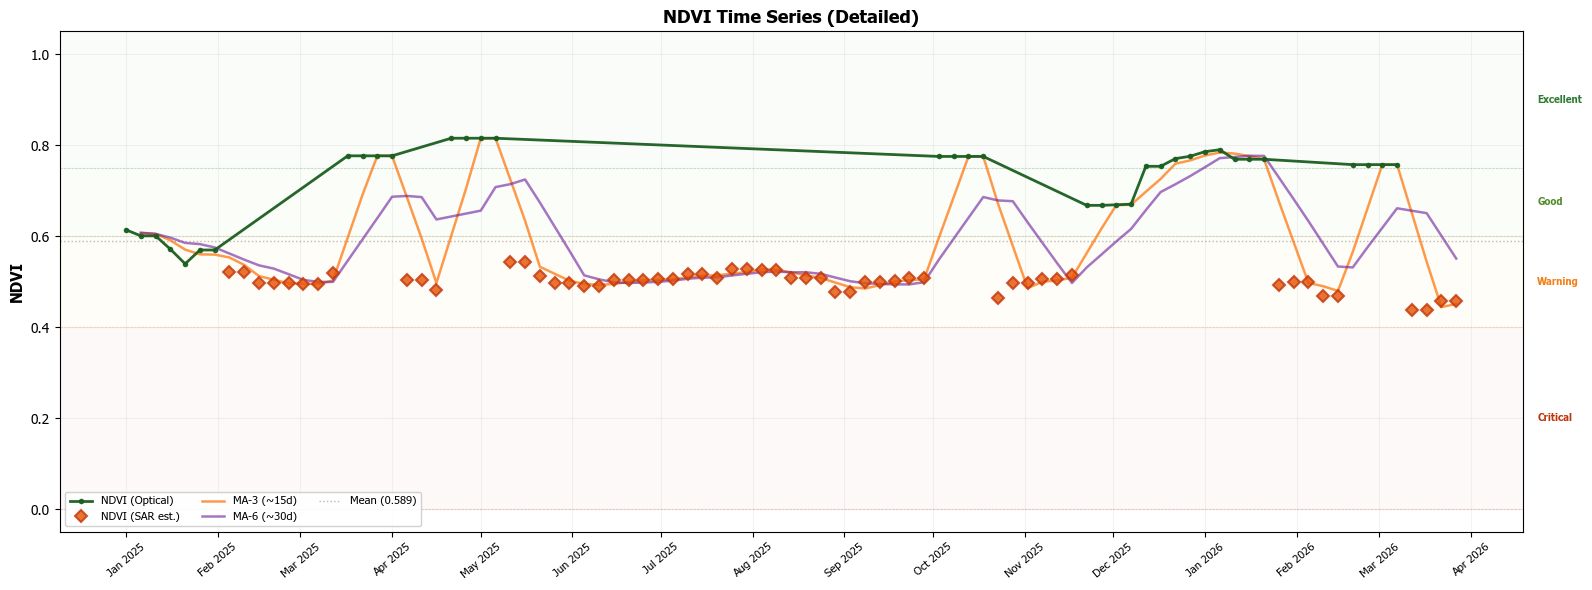

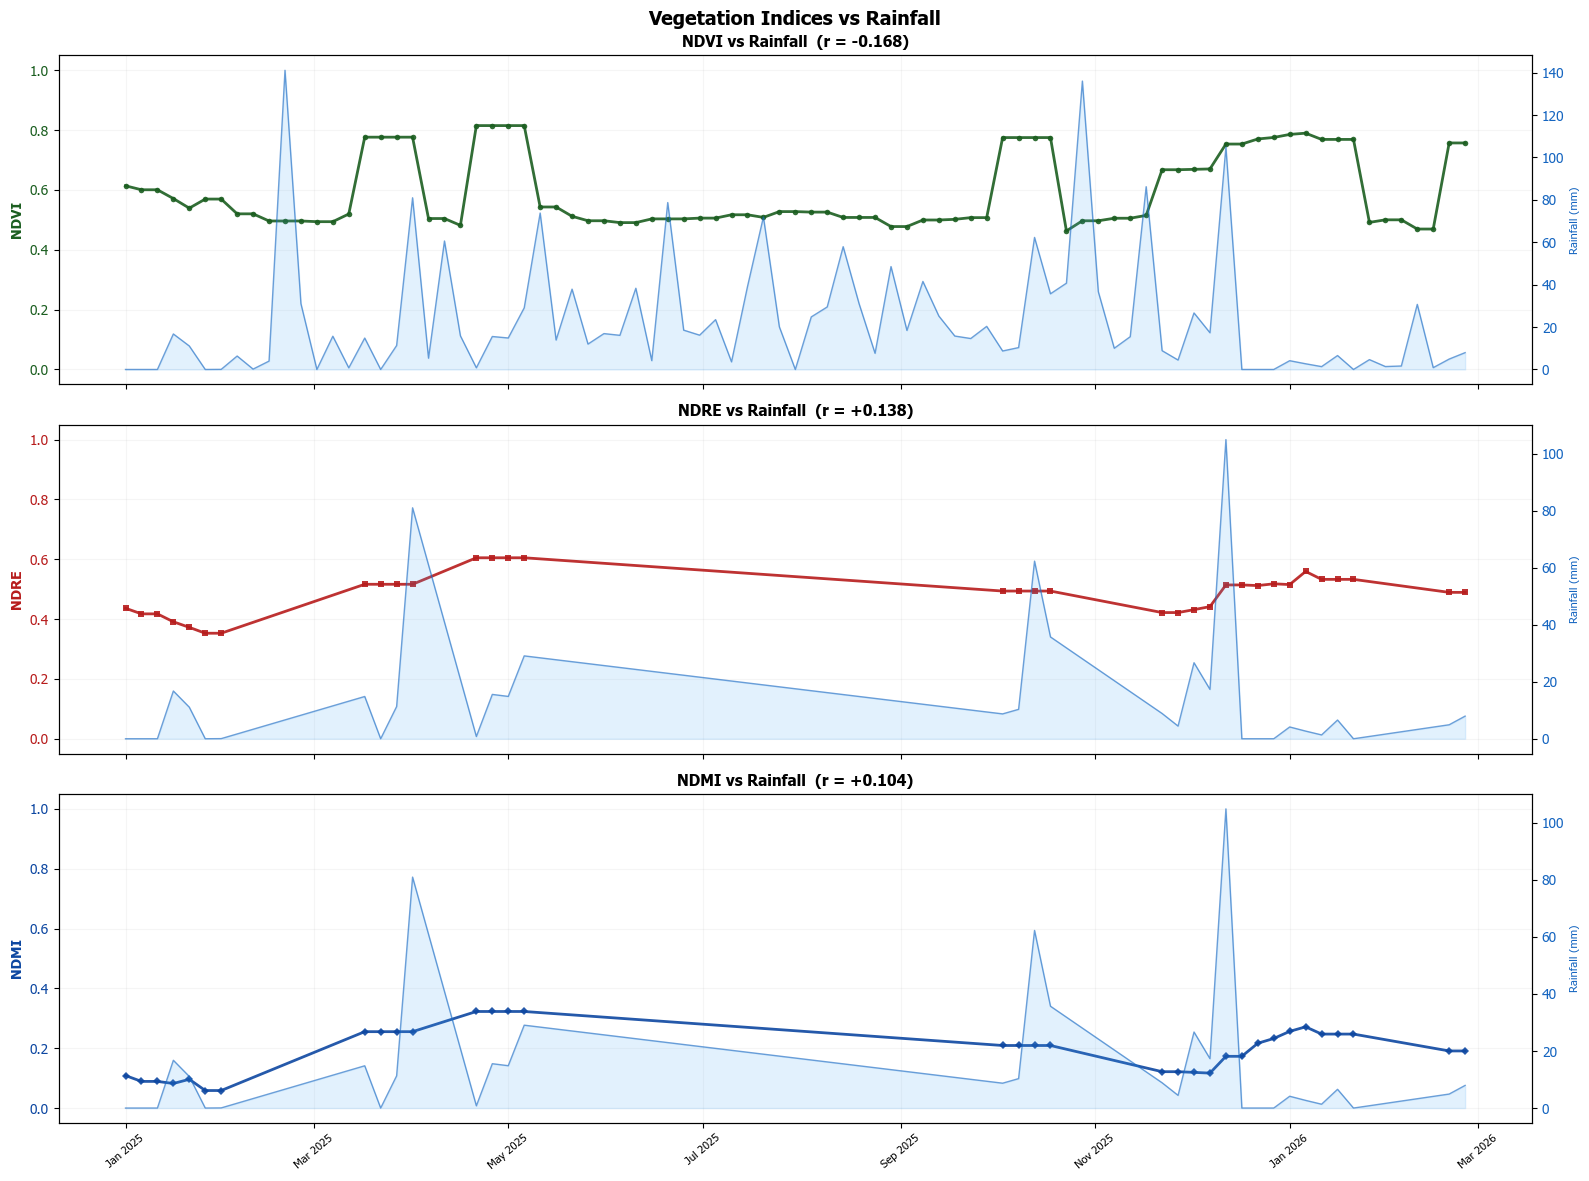

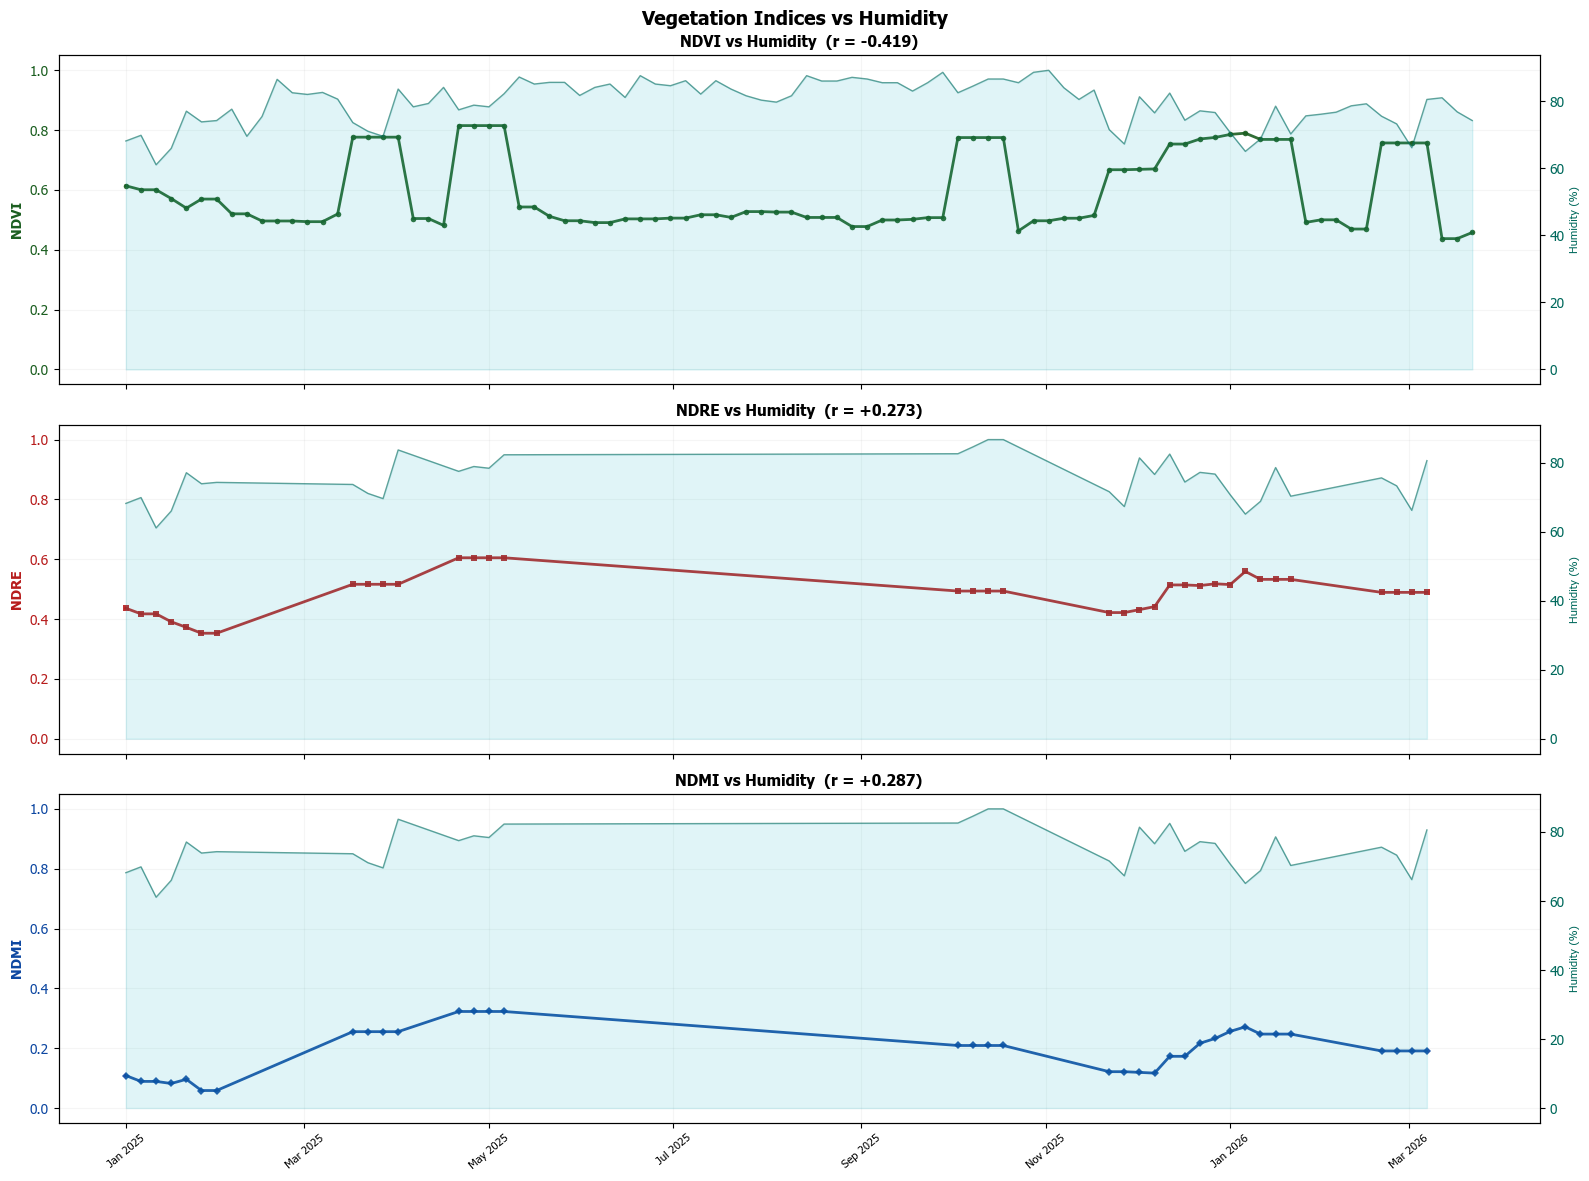

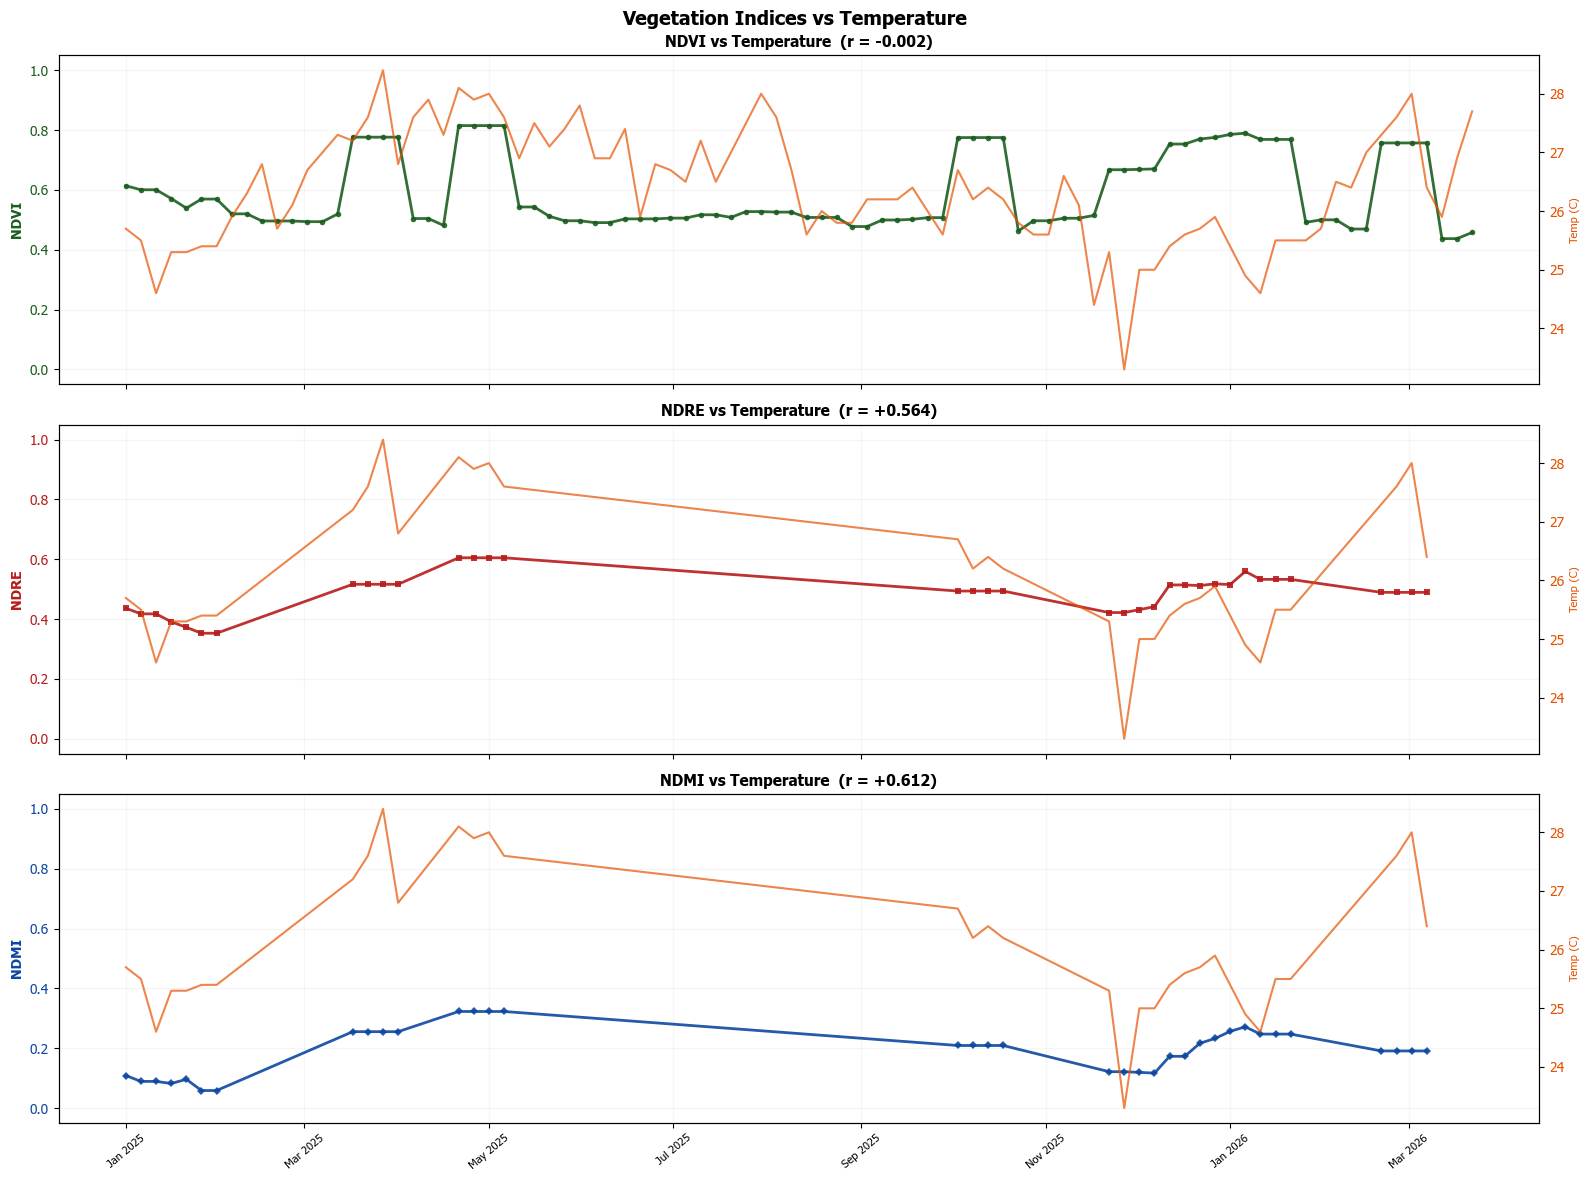

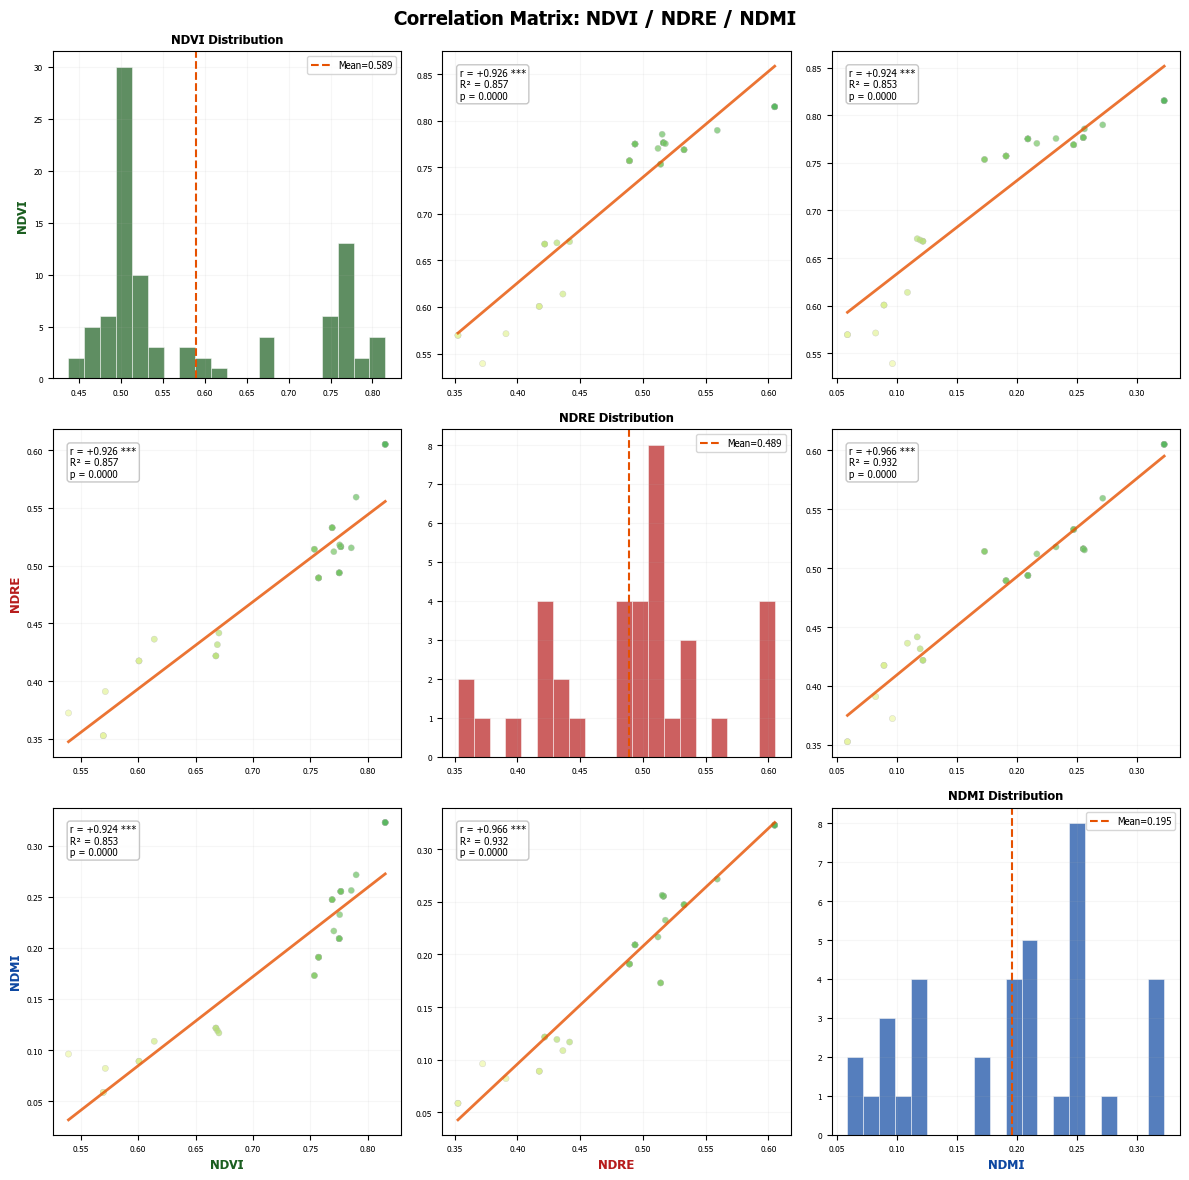


  Correlation Table:
               NDVI     NDRE     NDMI
  NDVI       +1.000   +0.926   +0.924
  NDRE       +0.926   +1.000   +0.966
  NDMI       +0.924   +0.966   +1.000


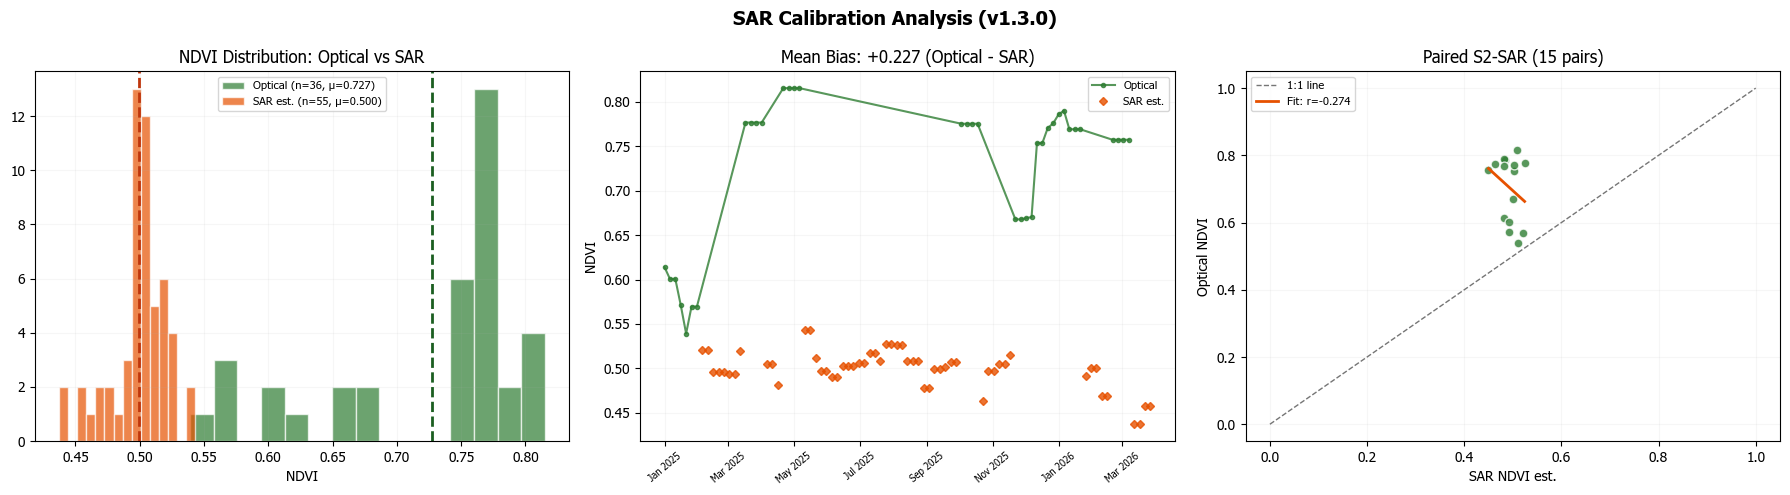


  All 6 analysis graphs generated! (v1.3.0)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from scipy import stats as sp_stats


# โหลดข้อมูล: ลองจาก global data_log ก่อน  - fallback Firebase
def load_analysis_data():
    global data_log

    try:
        if data_log and len(data_log) > 0:
            df = pd.DataFrame(data_log)
            if 'Date' in df.columns:
                df['Date'] = pd.to_datetime(df['Date'])
            elif 'date' in df.columns:
                df['Date'] = pd.to_datetime(df['date'])
            print(f"  ✅ โหลดจาก data_log สำเร็จ: {len(df)} records")
            return df
    except NameError:
        pass
    
   
    try:
        farm = farm_name_input.value if 'farm_name_input' in dir() else 'Banana_Farm_Zone_F'
        print(f"  📡 data_log ว่าง — กำลังโหลดจาก Firebase (farm: {farm})...")
        docs = db.collection('banana_indices_logs').where('farm_name', '==', farm).order_by('date').stream()
        records = [d.to_dict() for d in docs]
        if not records:
            print("  ❌ ไม่พบข้อมูลใน Firebase")
            return None
        df = pd.DataFrame(records)
        df['Date'] = pd.to_datetime(df['date'])
        print(f"  ✅ โหลดจาก Firebase สำเร็จ: {len(df)} records")
        return df
    except Exception as e:
        print(f"  ❌ Error loading data: {e}")
        return None

df = load_analysis_data()
if df is None:
    raise SystemExit("ไม่สามารถโหลดข้อมูลได้ — กรุณารัน Cell 1 ก่อน")



def clean(df):
    out = df.copy()
    if 'is_spike' in out.columns:
        out = out[~out['is_spike'].fillna(False)]
    return out.sort_values('Date').reset_index(drop=True)


# ══════════════════════════════════════════
# GRAPH 1: NDVI 
# ══════════════════════════════════════════
def plot_ndvi_only(df):
    cdf = clean(df)
    fig, ax = plt.subplots(figsize=(16, 6))
    
    zones = [(0.75,1.05,'#E8F5E9','Excellent','#2E7D32'),
             (0.60,0.75,'#F1F8E9','Good','#558B2F'),
             (0.40,0.60,'#FFF8E1','Warning','#F57F17'),
             (0.00,0.40,'#FBE9E7','Critical','#BF360C')]
    for y0,y1,bg,lbl,tc in zones:
        ax.axhspan(y0,y1,alpha=0.25,color=bg,zorder=0)
        ax.axhline(y=y0,color=tc,alpha=0.3,lw=0.5,ls='--')
        ax.text(1.01,(y0+y1)/2,lbl,transform=ax.get_yaxis_transform(),
                fontsize=7,color=tc,fontweight='bold',va='center')
    
    is_sar = cdf['source'].str.contains('SAR',na=False) if 'source' in cdf.columns else pd.Series([False]*len(cdf))
    is_opt = ~is_sar
    
    if is_opt.any():
        ax.plot(cdf.loc[is_opt,'Date'], cdf.loc[is_opt,'NDVI'], 'o-',
                color='#1B5E20', lw=2, ms=4, mew=0, alpha=0.95,
                label='NDVI (Optical)', zorder=10)
    if is_sar.any():
        ax.plot(cdf.loc[is_sar,'Date'], cdf.loc[is_sar,'NDVI'], 'D',
                color='#E65100', ms=6, mew=1.5, mec='#BF360C', alpha=0.8,
                label='NDVI (SAR est.)', zorder=11)
    
    ndvi = cdf['NDVI'].values
    for w, c, a, lbl in [(3,'#FF6F00',0.7,'MA-3 (~15d)'),(6,'#6A1B9A',0.6,'MA-6 (~30d)')]:
        if len(ndvi) >= w:
            ma = pd.Series(ndvi).rolling(w, min_periods=2).mean().values
            ax.plot(cdf['Date'], ma, '-', color=c, lw=1.8, alpha=a, label=lbl, zorder=8)
    
    mean_ndvi = np.nanmean(ndvi)
    ax.axhline(y=mean_ndvi, color='#757575', ls=':', lw=1, alpha=0.5,
              label=f'Mean ({mean_ndvi:.3f})')
    
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('NDVI', fontsize=11, fontweight='bold')
    ax.set_title('NDVI Time Series (Detailed)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8, ncol=3, framealpha=0.9)
    ax.grid(True, alpha=0.15)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', labelsize=8, rotation=40)
    plt.tight_layout()
    plt.show()

plot_ndvi_only(df)


# ══════════════════════════════════════════
# GRAPH 2: NDVI / NDRE / NDMI vs Rainfall
# ══════════════════════════════════════════
def plot_indices_vs_rainfall(df):
    cdf = clean(df)
    if 'rainfall_mm' not in cdf.columns:
        print("No rainfall data"); return
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('Vegetation Indices vs Rainfall', fontsize=14, fontweight='bold', y=0.98)
    
    indices = [('NDVI','#1B5E20','o'),('NDRE','#B71C1C','s'),('NDMI','#0D47A1','D')]
    
    for ax, (idx, color, mk) in zip(axes, indices):
        if idx not in cdf.columns: continue
        valid = cdf[['Date',idx,'rainfall_mm']].dropna()
        if len(valid) == 0: continue
        
        ax.plot(valid['Date'], valid[idx], f'{mk}-', color=color, lw=2, ms=4,
                mew=0, alpha=0.9, label=idx, zorder=10)
        ax.set_ylabel(idx, color=color, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color)
        ax.set_ylim(-0.05, 1.05)
        
        ax2 = ax.twinx()
        ax2.fill_between(valid['Date'], valid['rainfall_mm'], alpha=0.15, color='#42A5F5')
        ax2.plot(valid['Date'], valid['rainfall_mm'], '-', color='#1565C0',
                lw=1, alpha=0.6, label='Rainfall (mm)')
        ax2.set_ylabel('Rainfall (mm)', color='#1565C0', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='#1565C0')
        
        r = valid[idx].corr(valid['rainfall_mm'])
        ax.set_title(f'{idx} vs Rainfall  (r = {r:+.3f})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    axes[-1].tick_params(axis='x', labelsize=8, rotation=40)
    plt.tight_layout()
    plt.show()

plot_indices_vs_rainfall(df)


# ══════════════════════════════════════════
# GRAPH 3: NDVI / NDRE / NDMI vs Humidity
# ══════════════════════════════════════════
def plot_indices_vs_humidity(df):
    cdf = clean(df)
    if 'humidity_pct' not in cdf.columns:
        print("No humidity data"); return
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('Vegetation Indices vs Humidity', fontsize=14, fontweight='bold', y=0.98)
    
    indices = [('NDVI','#1B5E20','o'),('NDRE','#B71C1C','s'),('NDMI','#0D47A1','D')]
    
    for ax, (idx, color, mk) in zip(axes, indices):
        if idx not in cdf.columns: continue
        valid = cdf[['Date',idx,'humidity_pct']].dropna()
        if len(valid) == 0: continue
        
        ax.plot(valid['Date'], valid[idx], f'{mk}-', color=color, lw=2, ms=4,
                mew=0, alpha=0.9, label=idx, zorder=10)
        ax.set_ylabel(idx, color=color, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color)
        ax.set_ylim(-0.05, 1.05)
        
        ax2 = ax.twinx()
        ax2.fill_between(valid['Date'], valid['humidity_pct'], alpha=0.12, color='#00ACC1')
        ax2.plot(valid['Date'], valid['humidity_pct'], '-', color='#00695C',
                lw=1, alpha=0.6, label='Humidity (%)')
        ax2.set_ylabel('Humidity (%)', color='#00695C', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='#00695C')
        
        r = valid[idx].corr(valid['humidity_pct'])
        ax.set_title(f'{idx} vs Humidity  (r = {r:+.3f})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    axes[-1].tick_params(axis='x', labelsize=8, rotation=40)
    plt.tight_layout()
    plt.show()

plot_indices_vs_humidity(df)


# ══════════════════════════════════════════
# GRAPH 4: NDVI / NDRE / NDMI vs Temperature
# ══════════════════════════════════════════
def plot_indices_vs_temperature(df):
    cdf = clean(df)
    if 'temp_mean_c' not in cdf.columns:
        print("No temperature data"); return
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('Vegetation Indices vs Temperature', fontsize=14, fontweight='bold', y=0.98)
    
    indices = [('NDVI','#1B5E20','o'),('NDRE','#B71C1C','s'),('NDMI','#0D47A1','D')]
    
    for ax, (idx, color, mk) in zip(axes, indices):
        if idx not in cdf.columns: continue
        valid = cdf[['Date',idx,'temp_mean_c']].dropna()
        if len(valid) == 0: continue
        
        ax.plot(valid['Date'], valid[idx], f'{mk}-', color=color, lw=2, ms=4,
                mew=0, alpha=0.9, label=idx, zorder=10)
        ax.set_ylabel(idx, color=color, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color)
        ax.set_ylim(-0.05, 1.05)
        
        ax2 = ax.twinx()
        ax2.plot(valid['Date'], valid['temp_mean_c'], '-', color='#E65100',
                lw=1.5, alpha=0.7, label='Temp (C)')
        ax2.set_ylabel('Temp (C)', color='#E65100', fontsize=8)
        ax2.tick_params(axis='y', labelcolor='#E65100')
        
        r = valid[idx].corr(valid['temp_mean_c'])
        ax.set_title(f'{idx} vs Temperature  (r = {r:+.3f})', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.12)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    axes[-1].tick_params(axis='x', labelsize=8, rotation=40)
    plt.tight_layout()
    plt.show()

plot_indices_vs_temperature(df)


# ══════════════════════════════════════════════════
# GRAPH 5: Correlation Scatter Matrix (NDVI vs NDRE vs NDMI)
# ══════════════════════════════════════════════════
def plot_index_correlation(df):
    cdf = clean(df)
    indices = ['NDVI','NDRE','NDMI']
    avail = [c for c in indices if c in cdf.columns and cdf[c].notna().sum() >= 5]
    
    if len(avail) < 2:
        print("Need at least 2 indices with data"); return
    
    n = len(avail)
    fig, axes = plt.subplots(n, n, figsize=(12, 12))
    fig.suptitle('Correlation Matrix: NDVI / NDRE / NDMI', fontsize=14, fontweight='bold', y=0.98)
    
    colors = {'NDVI':'#1B5E20','NDRE':'#B71C1C','NDMI':'#0D47A1'}
    
    for i, yi in enumerate(avail):
        for j, xj in enumerate(avail):
            ax = axes[i][j] if n > 1 else axes
            
            if i == j:
                diag_data = cdf[yi].dropna()
                ax.hist(diag_data, bins=20, color=colors.get(yi,'#666'),
                       alpha=0.7, edgecolor='white', lw=0.5)
                ax.set_title(f'{yi} Distribution', fontsize=9, fontweight='bold')
                mean_v = diag_data.mean()
                ax.axvline(x=mean_v, color='#E65100', ls='--', lw=1.5,
                          label=f'Mean={mean_v:.3f}')
                ax.legend(fontsize=7)
            else:
                valid = cdf[[xj, yi]].dropna()
                x, y = valid[xj].values, valid[yi].values
                ndvi_for_color = cdf.loc[valid.index, 'NDVI'].values if 'NDVI' in cdf.columns else y
                ax.scatter(x, y, c=ndvi_for_color,
                          cmap='RdYlGn', s=20, alpha=0.7, edgecolors='#BDBDBD',
                          lw=0.3, vmin=0, vmax=1, zorder=5)
                
                if len(x) >= 3 and np.std(x) > 0.001:
                    slope, intercept, r, p_val, se = sp_stats.linregress(x, y)
                    xl = np.linspace(x.min(), x.max(), 50)
                    ax.plot(xl, slope*xl + intercept, '-', color='#E65100',
                           lw=2, alpha=0.8, zorder=10)
                    sig = "***" if p_val<0.001 else "**" if p_val<0.01 else "*" if p_val<0.05 else "ns"
                    ax.text(0.05, 0.95,
                           f'r = {r:+.3f} {sig}\nR² = {r**2:.3f}\np = {p_val:.4f}',
                           transform=ax.transAxes, fontsize=7, va='top',
                           bbox=dict(boxstyle='round', facecolor='white',
                                    alpha=0.85, edgecolor='#BDBDBD'))
            
            if i == n-1:
                ax.set_xlabel(xj, fontsize=9, fontweight='bold', color=colors.get(xj,'#000'))
            if j == 0:
                ax.set_ylabel(yi, fontsize=9, fontweight='bold', color=colors.get(yi,'#000'))
            ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.1)
    
    plt.tight_layout()
    plt.show()
    
    print("\n  Correlation Table:")
    print(f"  {'':8s}", end="")
    for c in avail: print(f" {c:>8s}", end="")
    print()
    for yi in avail:
        print(f"  {yi:8s}", end="")
        for xj in avail:
            if xj == yi:
                print(f" {1.000:+8.3f}", end="")  
            else:
                v = cdf[[xj,yi]].dropna()
                if len(v) >= 3:
                    r = v[yi].corr(v[xj])
                    print(f" {r:+8.3f}", end="")
                else:
                    print(f" {'N/A':>8s}", end="")
        print()

plot_index_correlation(df)


# ══════════════════════════════════════════════════
# GRAPH 6 (NEW v1.3.0): SAR Calibration Analysis
# ══════════════════════════════════════════════════
def plot_sar_calibration(df):
    
    cdf = clean(df)
    is_sar = cdf['source'].str.contains('SAR', na=False) if 'source' in cdf.columns else pd.Series([False]*len(cdf))
    is_opt = ~is_sar
    
    if not is_sar.any() or not is_opt.any():
        print("Need both SAR and optical data for calibration analysis")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('SAR Calibration Analysis (v1.3.0)', fontsize=14, fontweight='bold')
    
    # Panel 1: NDVI distribution comparison
    ax = axes[0]
    opt_ndvi = cdf.loc[is_opt, 'NDVI'].dropna()
    sar_ndvi = cdf.loc[is_sar, 'NDVI'].dropna()
    ax.hist(opt_ndvi, bins=15, alpha=0.7, color='#2E7D32', label=f'Optical (n={len(opt_ndvi)}, μ={opt_ndvi.mean():.3f})', edgecolor='white')
    ax.hist(sar_ndvi, bins=15, alpha=0.7, color='#E65100', label=f'SAR est. (n={len(sar_ndvi)}, μ={sar_ndvi.mean():.3f})', edgecolor='white')
    ax.axvline(opt_ndvi.mean(), color='#1B5E20', ls='--', lw=2)
    ax.axvline(sar_ndvi.mean(), color='#BF360C', ls='--', lw=2)
    ax.set_xlabel('NDVI')
    ax.set_title('NDVI Distribution: Optical vs SAR')
    ax.legend(fontsize=8)
    
    # Panel 2: Time series comparison
    ax = axes[1]
    ax.plot(cdf.loc[is_opt, 'Date'], cdf.loc[is_opt, 'NDVI'], 'o-', color='#2E7D32', ms=3, lw=1.5, label='Optical', alpha=0.8)
    ax.plot(cdf.loc[is_sar, 'Date'], cdf.loc[is_sar, 'NDVI'], 'D', color='#E65100', ms=4, label='SAR est.', alpha=0.8)
    bias = opt_ndvi.mean() - sar_ndvi.mean()
    ax.set_title(f'Mean Bias: {bias:+.3f} (Optical - SAR)')
    ax.set_ylabel('NDVI')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    
    # Panel 3: SAR calibration 
    ax = axes[2]
    try:
        if sar_calibration_pairs and len(sar_calibration_pairs) > 0:
            pairs = pd.DataFrame(sar_calibration_pairs)
            ax.scatter(pairs['sar_ndvi_est'], pairs['optical_ndvi'], c='#2E7D32', s=40, alpha=0.8, edgecolors='white')
            ax.plot([0,1],[0,1], '--', color='#757575', lw=1, label='1:1 line')
            if len(pairs) >= 3:
                slope, intercept, r, p_val, _ = sp_stats.linregress(pairs['sar_ndvi_est'], pairs['optical_ndvi'])
                xl = np.linspace(pairs['sar_ndvi_est'].min(), pairs['sar_ndvi_est'].max(), 50)
                ax.plot(xl, slope*xl+intercept, '-', color='#E65100', lw=2, label=f'Fit: r={r:.3f}')
            ax.set_xlabel('SAR NDVI est.')
            ax.set_ylabel('Optical NDVI')
            ax.set_title(f'Paired S2-SAR ({len(pairs)} pairs)')
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No paired\nS2-SAR data\n\nRun analysis first', 
                   transform=ax.transAxes, ha='center', va='center', fontsize=12, color='#999')
            ax.set_title('Paired S2-SAR Calibration')
    except NameError:
        ax.text(0.5, 0.5, 'sar_calibration_pairs\nnot available', 
               transform=ax.transAxes, ha='center', va='center', fontsize=11, color='#999')
        ax.set_title('Paired S2-SAR Calibration')
    
    for ax in axes:
        ax.grid(True, alpha=0.1)
    
    plt.tight_layout()
    plt.show()

plot_sar_calibration(df)


print("\n" + "="*50)
print("  All 6 analysis graphs generated! (v1.3.0)")
print("="*50)
